In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)


    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """ Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False

def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [5]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state==self.goal


    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols


    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.

        legal_actions =[]
        row, col = state
        for action, (dr,dc) in MOVES.items():
          new_state = (row+dr, col+dc)

          if self.in_bounds(new_state) and self.is_free(new_state):
            legal_actions.append(action)

        return legal_actions


    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1



In [6]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [7]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()



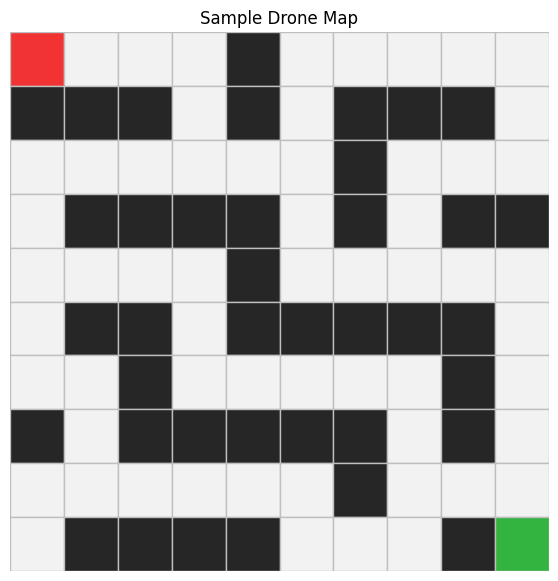

In [8]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [9]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)


        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)

            yield Node(s_prime,node,action, cost)


    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

BREADTH-FIRST-SEARCH(problem)
    node ← NODE(problem.INITIAL)

    if problem.IS-GOAL(node.STATE) then
        return node

    frontier ← a FIFO queue with node as an element
    reached ← {problem.INITIAL}

    while frontier is not empty do
        node ← POP(frontier)          // remove from the front of the queue

        for each child in EXPAND(problem, node) do
            s ← child.STATE

            if problem.IS-GOAL(s) then
                return child

            if s is not in reached then
                add s to reached
                add child to frontier // add to the back of the queue

    return failure
Python structure to think about: BFS uses deque, popleft(), and append().

In [10]:
 # TO DO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. If the initial state is the goal, return success.
        # 3. Create a deque frontier and add the initial node.
        # 4. Create a reached set and add the initial state.
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.

class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        initial_state = problem.initial_state()
        initial_node = Node(
            state=initial_state,
            parent=None,
            action=None,
            path_cost=0
        )

        if problem.is_goal(initial_state):
            return SearchResult.success(
                algorithm=algorithm,
                node=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=len(reached)
            )

        frontier = deque([initial_node])
        reached = set([initial_state])

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:

            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                state = child.state

                if problem.is_goal(state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached)
                    )

                if state not in reached:
                    reached.add(state)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)

)

In [11]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        initial_state = problem.initial_state()
        initial_node = Node(state= initial_state, parent=None,action=None,path_cost = 0)

        if problem.is_goal(initial_state):
          return SearchResult.success(
              algorithm=algorithm,
              node=initial_node,
              nodes_expanded=0,
              max_frontier_size=1,
              reached_count=len(reached)
            )

        frontier = list([initial_node])

        reached = set([initial_state])
        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
         node = frontier.pop()
         nodes_expanded += 1

         for child in self.expand(problem, node):
           state = child.state


           if problem.is_goal(state):
             return SearchResult(
                 algorithm=algorithm,
                 status="success",
                 solution=child,
                 nodes_expanded=nodes_expanded,
                 max_frontier_size=max_frontier_size,
                 reached_count=len(reached)
                   )


           if state not in reached:
            reached.add(state)
            frontier.append(child)

        max_frontier_size = max(max_frontier_size, len(frontier))


        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
)




        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        # 3. Use a Python list as the stack frontier.
        # 4. Use a reached set.
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.






In [12]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(
            state=problem.initial_state(),
            parent=None,
            action=None,
            path_cost=0
            )

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").

        if problem.is_goal(node.state):
          return node, "success"
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        if node.depth >= limit:
          return None,"cutoff"

        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        metrics["nodes_expanded"] += 1

        #       b. set cutoff_occurred = False.
        cutoff_occurred = False
        #       c. for each child in expand(problem, node):



        for child in self.expand(problem, node):
              #             i. skip the child if child.state already appears on the current path.

             #            ii. update max_stack_size.

           current_stack_size += 1
           metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size)

                 #           iii. recursively call _recursive_dls on the child.

           result_node, status = self._recursive_dls(
             problem,
             child,
             limit,
             metrics,
             current_stack_size
         )


  #            iv. if result is "success", return success immediately.

           if status == "success":
            return result_node, "success"
   #             v. if result is "cutoff", set cutoff_occurred = True.
           if status == "cutoff":
            cutoff_occurred = True


       #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")
        if cutoff_occurred:
         return None, "cutoff"
        else:
         return None, "failure"

In [13]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        dls = DepthLimitedSearch()




         # 1. Keep a list called iteration_log.
        iteration_log = []
         # 2. Accumulate total nodes expanded across all DLS iterations.
        total_nodes_expanded = 0
# 3. Track the maximum stack size seen in any DLS run.
        max_stack_size = 0

       # 4. If a DLS run returns success, return a SearchResult for IDS.

        for limit in range(max_depth + 1):

            result = dls.search(problem, limit=limit)
            iteration_log.append(result)

            total_nodes_expanded += result.nodes_expanded
            max_stack_size = max(max_stack_size, result.max_frontier_size)


            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                )

              # 5. If a DLS run returns failure, IDS can stop early and return failure.

            if result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                )
          # 6. If all limits return cutoff up to max_depth, return cutoff.

        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
        )

            #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)

In [14]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,18.0,18.0,18,1,21
2,DLS,cutoff,10.0,NaN,NaN,313,22,0
3,IDS,success,NaN,18.0,18.0,219263,41,0


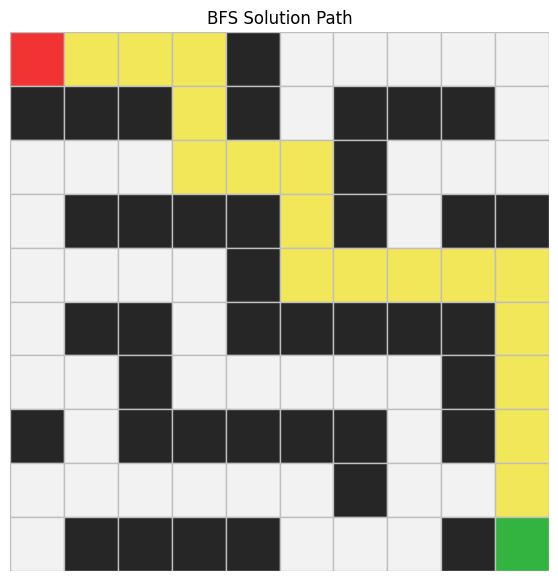

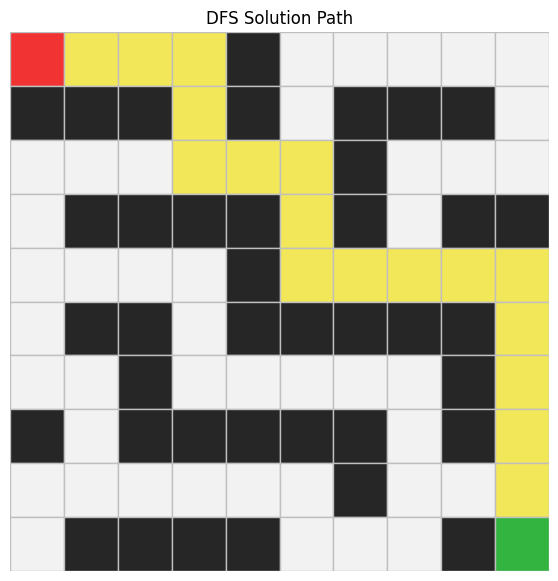

In [15]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [17]:
# TODO 10:
# Create your first custom map here.


custom_grid_1 = [
    [0,0,0,0,0,0,0],
    [1,1,1,1,1,0,1],
    [0,0,0,0,1,0,1],
    [0,1,1,0,1,0,1],
    [0,1,0,0,0,0,1],
    [0,1,1,1,1,1,1],
    [0,0,0,0,0,0,0]

]

custom_start_1 = (0,0)
custom_goal_1 = (6,6)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40), ]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,26.0,26.0,28,2,28
1,DFS,success,NaN,26.0,26.0,28,1,28
2,DLS,cutoff,20.0,NaN,NaN,329937,41,0
3,IDS,success,NaN,26.0,26.0,46507821,52,0


In [18]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0,0,0],
    [0,0,0],
    [0,0,0],
]

custom_start_2 = (0,0)
custom_goal_2 = (2,2)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
        bfs.search(custom_problem_2),
        dfs.search(custom_problem_2),
        dls.search(custom_problem_2, limit=20),
        ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,4,4,7,3,8
1,DFS,success,NaN,4,4,4,1,6
2,DLS,success,20.0,20,20,24,25,0
3,IDS,success,NaN,4,4,21,9,0


**15.1 Problem Formulation**


1.   What is a state in this lab?

A state is the location in the grid which is represented by row,col=state

2.   What is an action?

An action is a movement which the drone can make from its current location. Eg, up, down, left or right.

3. What does the result function do?

The result function returns the new state that is reached after an action is done on a currrent state.

4. Why is it useful to separate the problem definition from the search algorithm?

This ensures the reusability of the code we write. If we combine them we may have to change some parts of the code to cater for specific types of problems.







**15.2 BFS**

1. Why does BFS use a FIFO queue?

This is because in the queue the nodes are added in the manner in which they are discovered, and FIFO allows us to expand level by level to make sure the oldest added node is expanded first.

2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid?

This is because BFS explores the nodes at the current depth before moving on to the next. Due to this, the first ever time it reaches a goal has the shortest moves.

3. What role does the reached set play in BFS?

It prevents our search algorithm, from revisting states hat have been expanded already ,which can cause repeated states and cycles.

**15.3 DFS**

1. Why does DFS use a stack?

DFS uses a stack because a stack is a LIFO queue which means the last discovered node is expanded first. DFS aims to go down as far as possible before coming back , which can be achieved with a stack .

2. Is DFS guaranteed to find the shortest path? Explain.

No it isn't . This is because it returns the first solution that reaches the goal, but that may not be the shortest among the others.

3. Under what conditions can DFS use less memory than BFS?

If the target is deep in the graph, DFS would use less memory because with expanding linearly, it would probably find the solution with less effort.

Also,if there is a high branching factor for the nodes, DFS would use less memory because BFS would have to store the whole level of all those nodes.

A smaller depth would make DFS use less memory as compared to BFS which would depend on the number of nodes expanded at each level.

4. Under what conditions can DFS perform badly?

DFS can perform badly where there are complex graphs or cycles because it can get stuck in an infinite loop.

Also, if the goal is close to the initial node, it can waste time and memory expanding linearly.

When nodes are not tracked as it expands, it could also lead to the infinite looping mentioned earlier.


**15.4 DLS**

1. What happens when the depth limit is too small?

The goal may not be reached as the search algorithm could fail, even if there exists a path to that goal.

2. What is the meaning of "cutoff"?

This means that the serch algorithm stopped due to the depth limit being reached before a solution was found.

3. How is DLS different from ordinary DFS?

DLS introduces a maximum depth to what can be explored whilst DFS has no depth limit.

4. Why do we use path-cycle checking in DLS?

To prevent repeated states that can cause loops and time wasting.
Additionally, memory is saved as we prevent the tracking of every node visited. The path cycle just checks the path that is currently being explored.




**15.5 IDS**

1. Why does IDS repeat DLS with increasing limits?

This is because the goal depth is unknown and so the limit increases till it is found.

2. Why can IDS be complete even though DLS with a small limit is not?

The small limit on the DLS could prevent the algorithm from reaching the goal if its depth is larger. IDS, which is iterative, keeps increasing the limit until any goal state is reached.

3. Why does IDS use less memory than BFS?

IDS uses less memory because only the current search path is stored even with each iteration, however, BFS stores frontiers of all its nodes.

4. What is the cost of repeatedly searching from the root?

An increased computation level which eventually affects the time spent on this search algorithm.

**15.6 Real-World Drone Context**

1. In a real drone application, what might make one route safer or more practical than another?

Weather conditions, battery consumption, air restrictions, Communication coverage and even safety from foreign objects can determine whether one route is safer or more practical.

2. Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.

I would choose the BFS. This is because if all actions have the same cose, it would return the shortest path to the goal.

3. Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.

I would choose the DLS. Not only because of its name, but also the fact that it has a depth limit which ensures the drone does not explore deeper than specified.

4. What limitations does this grid model have compared with real drone navigation?

The grid problem is simple whereas real life situations are naturally far from simple. The grid problem does not take into account the factors we mentioned earlier for a real life drone application, i.e Battery consumption, weather conditions and so on. Additionally, things can occur in real time, which could require more complex decision making.